In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# set seaborn style
sns.set_style("white")
sns.set_context("talk")

In [3]:
# set random seed
seed = 42

In [4]:
# intialize shap
shap.initjs()

In [5]:
# import data
df = pd.read_csv("../data/processed/corpus_studio_processed.csv")
df.drop(
    columns=["performance_type", "group"], inplace=True
)  # for this study, only studio recordings were included
df.fillna(
    "", inplace=True
)  # replace NaN values for previous and next words with empty strings
df.head()

,word,previous_word,next_word,artist,song_type,song,aae_feature,aae_realization,time,social_group
0,first,the,thing,muddywaters,cover,rollin_stone,post-consonantal t,1,1960s,AA
1,your,rock,baby,tenyearsafter,original,rock_your_mama,post-vocalic r,1,1960s,nonAA_nonUS
2,for,do,you,bbking,original,please_love_me,post-vocalic r,0,1960s,AA
3,end,wanna,it,robertcray,original,smoking_gun,post-consonantal d,1,1980s,AA
4,serves,it,me,johnleehooker,cover,it_serves_me_right,third person singular,0,1980s,AA


In [6]:
# import model
model = CatBoostClassifier()
model.load_model(fname="../models/model.json", format="json")

# define target and predictor columns
target_col = "aae_realization"
X = df.loc[:, df.columns != target_col]
y = df.loc[:, target_col]

In [7]:
# create train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)
# get predictions
y_pred = model.predict(X_test)

# get classification report
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.84      0.77      0.81      1219
           1       0.92      0.95      0.93      3311

    accuracy                           0.90      4530
   macro avg       0.88      0.86      0.87      4530
weighted avg       0.90      0.90      0.90      4530



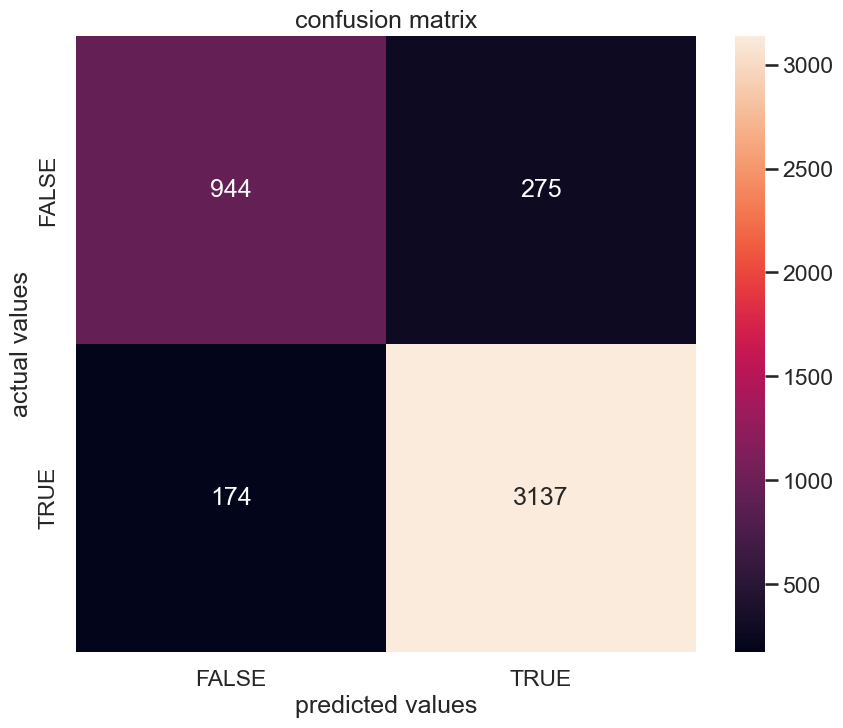

In [8]:
# generate confusion matrix with final model
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["FALSE", "TRUE"], columns=["FALSE", "TRUE"])
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="g")
plt.title("confusion matrix")
plt.ylabel("actual values")
plt.xlabel("predicted values")
plt.savefig("../reports/figures/confusion_matrix.png", dpi=600)
plt.show()

In [9]:
# calculate shap values
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

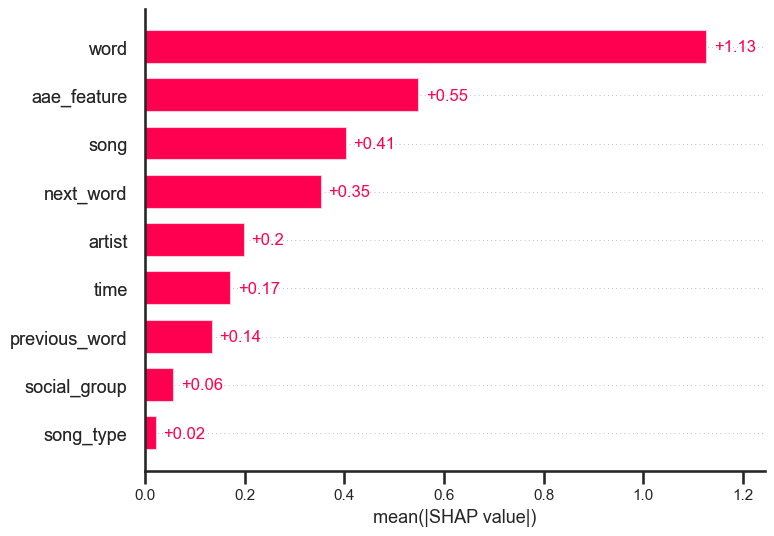

In [10]:
# mean shap values for each feature
shap.plots.bar(shap_values, show=False)
plt.savefig("../reports/figures/shap_bar.png", dpi=600, bbox_inches="tight")
plt.show()

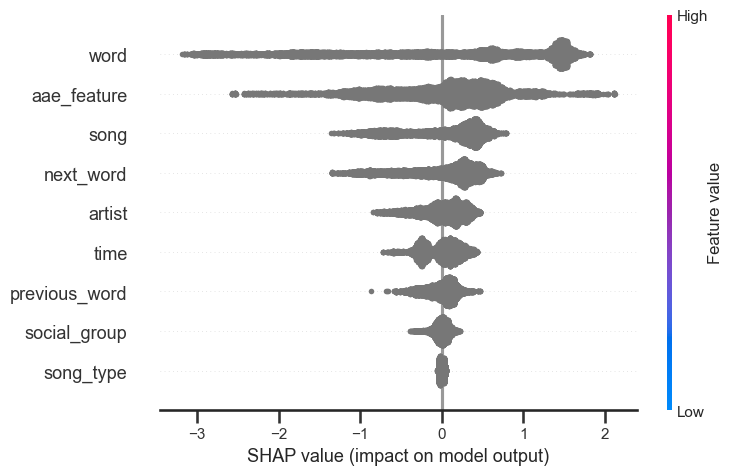

In [39]:
# beeswarm plot (not useful for categorical features)
shap.summary_plot(shap_values)

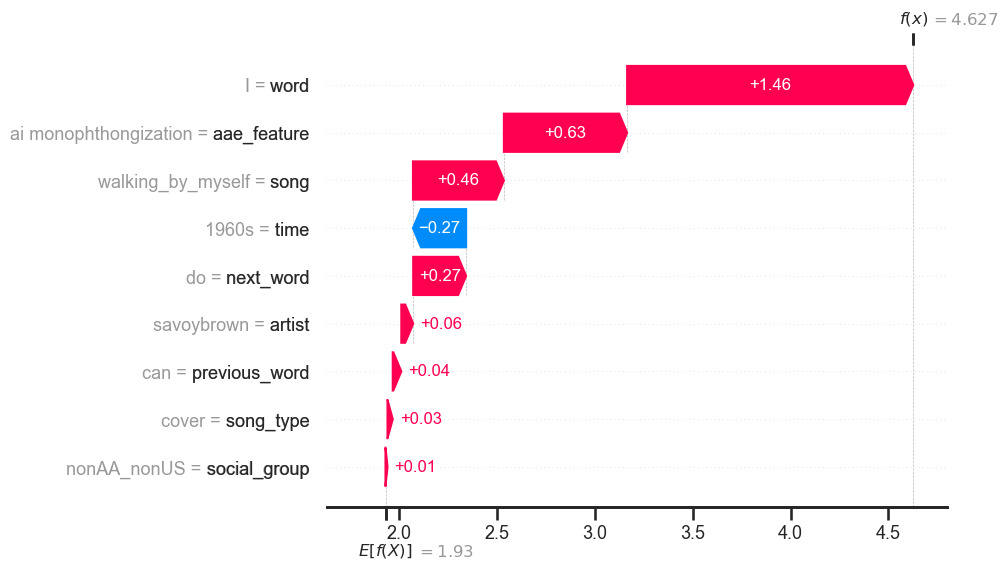

In [11]:
# waterfall plot for individual predictions
shap.plots.waterfall(shap_values[700], show=False)
plt.savefig("../reports/figures/shap_waterfall.png", dpi=600, bbox_inches="tight")
plt.show()

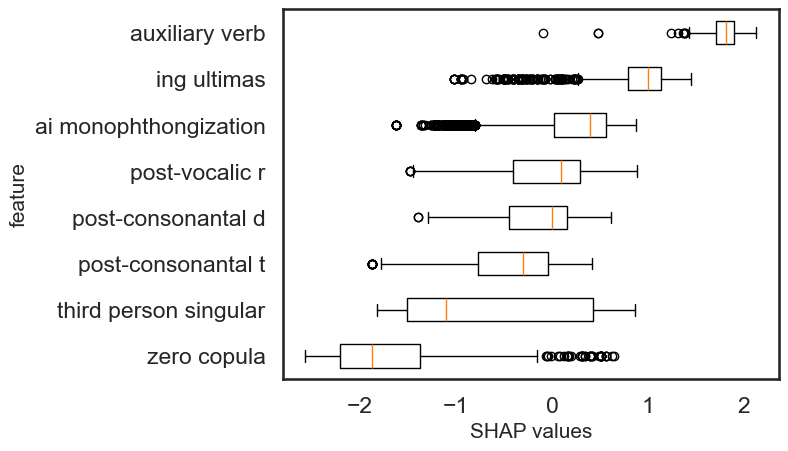

In [45]:
# get shap values and data
feature_values = shap_values[:, "aae_feature"].values
feature_data = shap_values[:, "aae_feature"].data

# get list of features
feature_list = df["aae_feature"].unique()

# split shap values based on feature
feature_groups = []
for a in feature_list:
    relevant_values = feature_values[feature_data == a]
    feature_groups.append(relevant_values)

# calculate the mean SHAP value for each feature
mean_shap_values = [np.mean(values) for values in feature_groups]

# sort features based on their mean SHAP values
sorted_indices = np.argsort(mean_shap_values)
sorted_feature_list = feature_list[sorted_indices]
sorted_feature_groups = [feature_groups[i] for i in sorted_indices]

# plot boxplot with sorted data
plt.boxplot(sorted_feature_groups, labels=sorted_feature_list, vert=False)
plt.xlabel("SHAP values", size=15)
plt.ylabel("feature", size=15)
plt.xticks(rotation=0)
plt.savefig("../reports/figures/shap_box_feature.png", dpi=600, bbox_inches="tight")
plt.show()

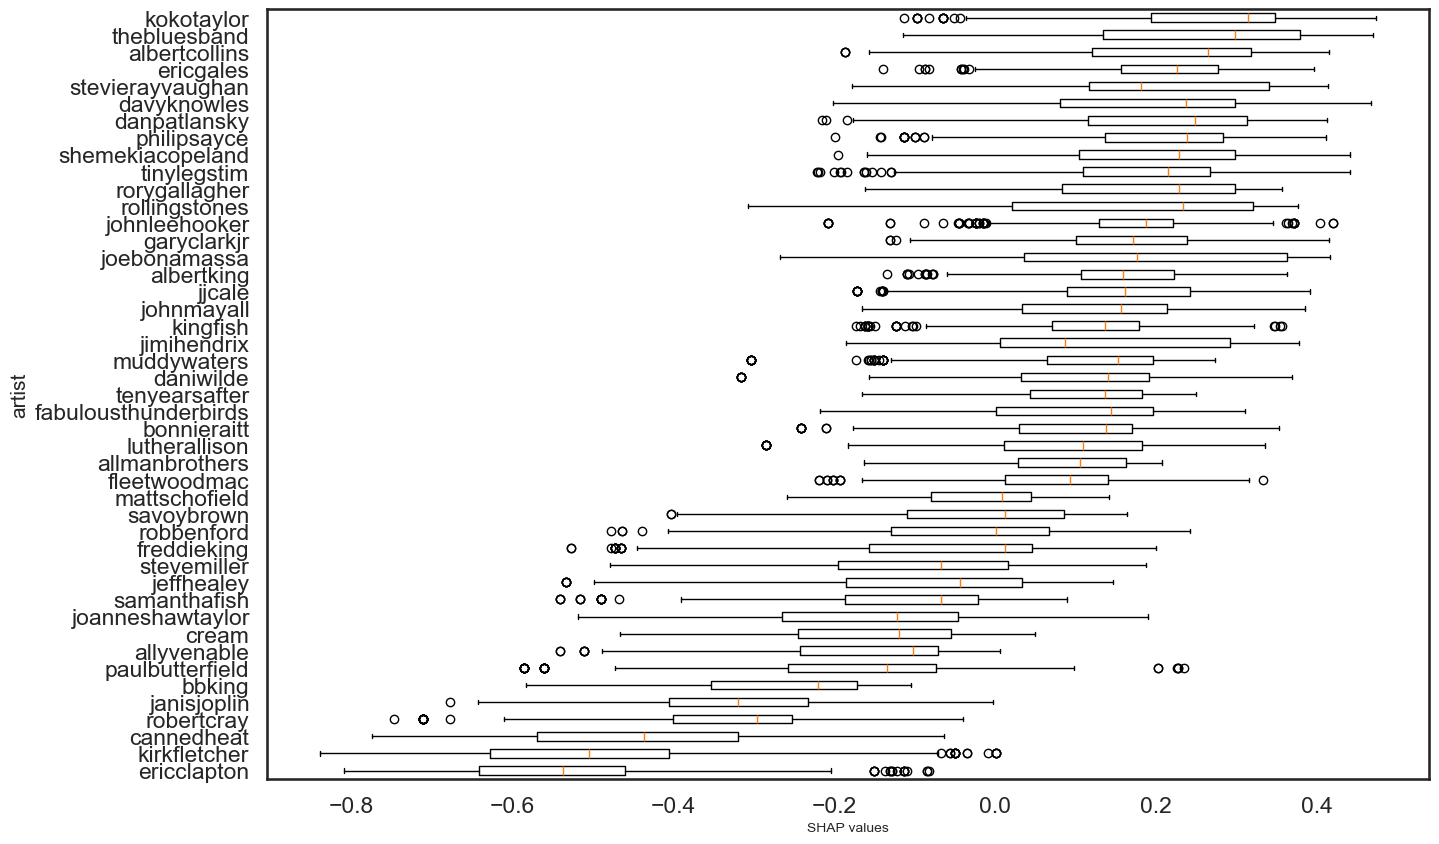

In [46]:
# get shap values and data
artist_values = shap_values[:, "artist"].values
artist_data = shap_values[:, "artist"].data

# get list of artists
artist_list = df["artist"].unique()

# split shap values based on artist
artist_groups = []
for a in artist_list:
    relevant_values = artist_values[artist_data == a]
    artist_groups.append(relevant_values)

# calculate the mean SHAP value for each artist
mean_shap_values = [np.mean(values) for values in artist_groups]

# sort artists based on their mean SHAP values
sorted_indices = np.argsort(mean_shap_values)
sorted_artist_list = artist_list[sorted_indices]
sorted_artist_groups = [artist_groups[i] for i in sorted_indices]

# plot boxplot with sorted data
plt.figure(figsize=(15, 10))
plt.boxplot(sorted_artist_groups, labels=sorted_artist_list, vert=False)
plt.ylabel("artist", size=15)
plt.xlabel("SHAP values", size=10)
plt.xticks(rotation=0)
plt.savefig("../reports/figures/shap_box_artist.png", dpi=600, bbox_inches="tight")
plt.show()

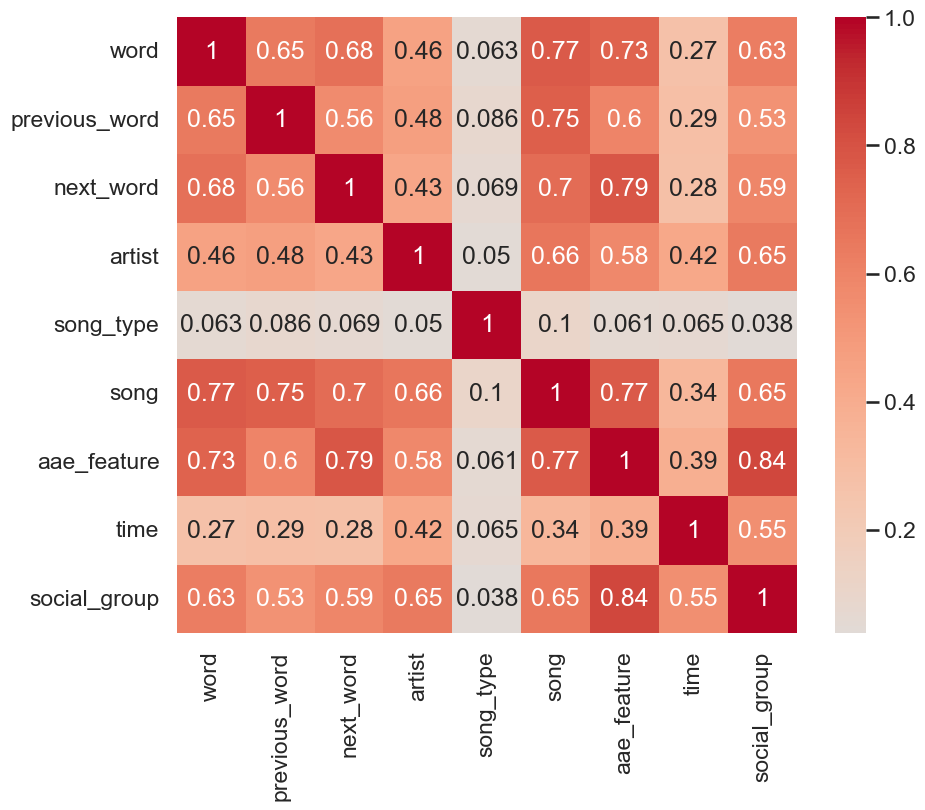

In [14]:
# correlation matrix of shap values for each feature
corr_matrix = pd.DataFrame(shap_values.values, columns=X.columns).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0.0, annot=True)
plt.show()